# Задачи 13–14

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f

n1 = 139
n2 = 100
alpha = 0.05

s1_len, s2_len = 5.722, 6.161
s1_wid, s2_wid = 4.612, 5.055

Delta_len = (s1_len ** 2) / (s2_len ** 2)
Delta_wid = (s1_wid ** 2) / (s2_wid ** 2)

print('Наблюдаемая статистика для длины  delta =', Delta_len)
print('Наблюдаемая статистика для ширины delta =', Delta_wid)

df1 = n1 - 1
df2 = n2 - 1

c1 = f.ppf(alpha / 2, df1, df2)
c2 = f.ppf(1 - alpha / 2, df1, df2)

print('c1 =', c1)
print('c2 =', c2)

print('Для длины: отвергаем H0?', Delta_len < c1 or Delta_len > c2)
print('Для ширины: отвергаем H0?', Delta_wid < c1 or Delta_wid > c2)

Наблюдаемая статистика для длины  delta = 0.8625678945904338
Наблюдаемая статистика для ширины delta = 0.8324080612765026
c1 = 0.6967596802842897
c2 = 1.4513964701711382
Для длины: отвергаем H0? False
Для ширины: отвергаем H0? False


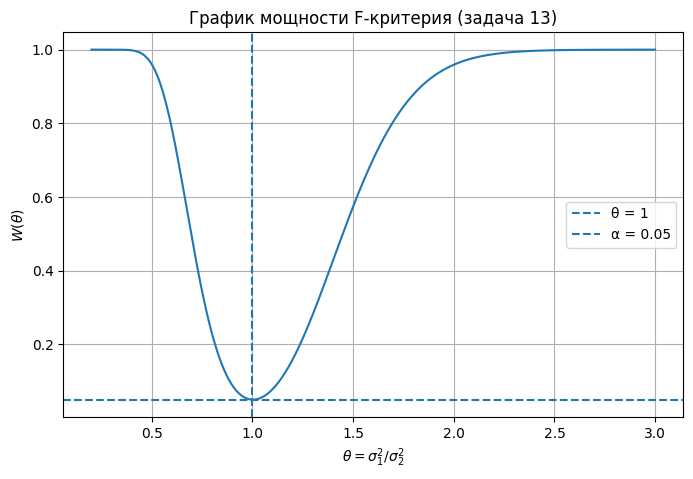

In [17]:
theta_grid = np.linspace(0.2, 3.0, 1000)

# W(theta) = F(c1/theta) + 1 - F(c2/theta)
power_13 = f.cdf(c1 / theta_grid, df1, df2) + 1 - f.cdf(c2 / theta_grid, df1, df2)

plt.figure(figsize=(8, 5))
plt.plot(theta_grid, power_13)
plt.axvline(1.0, linestyle='--', label='θ = 1')
plt.axhline(alpha, linestyle='--', label='α = 0.05')
plt.xlabel(r'$\theta = \sigma_1^2 / \sigma_2^2$')
plt.ylabel(r'$W(\theta)$')
plt.title('График мощности F-критерия (задача 13)')
plt.grid(True)
plt.legend()
plt.show()

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

x = np.array([-1.11, -6.10,  2.42])
y = np.array([-2.29, -2.91])

n = len(x)
m = len(y)

sigma2_x = 2
sigma2_y = 1

x_bar = x.mean()
y_bar = y.mean()

delta_hat = x_bar - y_bar

sd = np.sqrt(sigma2_x / n + sigma2_y / m)

Delta_obs = delta_hat / sd

p_value = 1 - norm.cdf(Delta_obs)

print('x̄ =', x_bar)
print('ȳ =', y_bar)
print('x̄ - ȳ =', delta_hat)
print('sqrt(7/6) =', sd)
print('Наблюдаемая статистика delta =', Delta_obs)
print('p-value =', p_value)

x̄ = -1.5966666666666667
ȳ = -2.6
x̄ - ȳ = 1.0033333333333334
sqrt(7/6) = 1.0801234497346432
Наблюдаемая статистика delta = 0.9289061667717935
p-value = 0.1764688584122911


In [19]:
# Проверка гипотезы на уровнях 0.05 и 0.10

for alpha_check in [0.05, 0.10]:
    u = norm.ppf(1 - alpha_check)
    reject = Delta_obs > u
    print(f'alpha = {alpha_check:.2f}, u_(1-alpha) = {u:.6f}, отвергаем H0? -> {reject}')

alpha = 0.05, u_(1-alpha) = 1.644854, отвергаем H0? -> False
alpha = 0.10, u_(1-alpha) = 1.281552, отвергаем H0? -> False


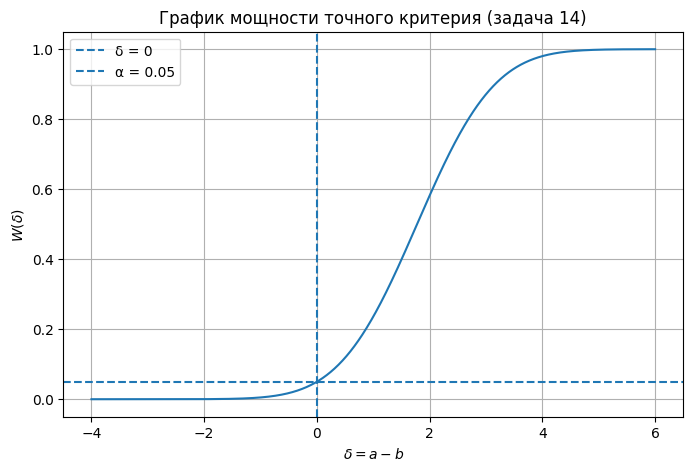

In [20]:
alpha = 0.05
u = norm.ppf(1 - alpha)

# delta = a - b
delta_grid = np.linspace(-4, 6, 1000)

# W(delta) = 1 - Phi(u_(1-alpha) - delta/sd)
power_14 = 1 - norm.cdf(u - delta_grid / sd)

plt.figure(figsize=(8, 5))
plt.plot(delta_grid, power_14)
plt.axvline(0.0, linestyle='--', label='δ = 0')
plt.axhline(alpha, linestyle='--', label='α = 0.05')
plt.xlabel(r'$\delta = a-b$')
plt.ylabel(r'$W(\delta)$')
plt.title('График мощности точного критерия (задача 14)')
plt.grid(True)
plt.legend()
plt.show()